# E-Commerce Marketing ROI Analysis: Capstone Project

**Objective:** Evaluate marketing performance across all channels and campaigns to determine which channels drive sustainable, profitable growth and how to optimally allocate next month's budget.

**Dataset:** 7 files covering 660,000+ sessions, 16,000+ orders, 40 campaigns across 5 channels (Jul 2025 – Jan 2026)

**Deliverables:** ETL Pipeline → Attribution Model → Regression Analysis → Segment Deep Dive → Budget Reallocation Plan

# Part A: Business Problem Framing

## 1. Business Objective

The objective of this analysis is to evaluate marketing performance across channels and campaigns to determine which channels drive sustainable, profitable growth.
The goal is not just to maximize revenue, but to optimize marketing spend based on contribution margin and long-term profitability.

---

## 2. North Star Metric

The selected North Star Metric is:

**Contribution Margin ROAS (Contribution Margin / Marketing Spend)**

Reason:
- Revenue does not account for product costs; plain revenue ROAS can be misleading.
- Contribution Margin ROAS reflects true profitability per rupee spent, after deducting cost of goods sold.
- Optimizing for Margin ROAS ensures marketing investment drives sustainable profit, not just topline growth.
- It is actionable: a channel with Margin ROAS > 1 is profitable on a contribution basis; below 1 it is destroying value.

---

## 3. Supporting KPIs

The following KPIs support the North Star metric:

1. ROAS (Revenue / Spend) — headline efficiency ratio
2. Margin ROAS (Contribution Margin / Spend) — **North Star KPI**
3. CAC Proxy (Spend / Orders) — cost to acquire a converting customer
4. Conversion Rate (Orders / Sessions) — session quality measure
5. Revenue per Session (Attributed Revenue / Total Sessions) — monetisation efficiency per visit
6. AOV, Average Order Value (Revenue / Orders) — basket size
7. Discount Rate (Discount Amount / Gross Amount) — promotional intensity
8. Channel Mix Share (% of total spend and % of total revenue per channel)
9. Click-Through Rate, CTR (Clicks / Impressions) — ad creative effectiveness
10. CPC (Spend / Clicks) — paid media cost efficiency
11. Margin per Channel (Attributed Contribution Margin by Channel) — profit attribution
12. New vs Returning Customer Order Share — retention vs acquisition balance

---

## 4. Attribution Rule

This analysis uses a **Last-Touch Attribution Model**:

Revenue and margin are attributed to the campaign associated with the user’s last session before purchase.

This is implemented by:
- Joining sessions with orders on session_id
- Assigning purchase_flag at session level
- Aggregating attributed revenue and orders at campaign-day level

---

## 5. Key Stakeholder Questions

This analysis aims to answer:

1. Which marketing channels generate the highest profitability?
2. Which campaigns are overfunded relative to their returns?
3. Are we scaling unprofitable channels?
4. How does performance differ by user segment and device?
5. What is the incremental impact of marketing spend?
6. How should next month’s budget be reallocated?

# Part B: Data Engineering & ETL Pipeline

Before any analysis can happen, we need to turn 7 raw CSV and JSON files into clean, reliable analytical tables. This section documents every step of that process.

The pipeline covers:
1. Loading and validating all raw datasets
2. Removing duplicate records
3. Handling missing values
4. Standardizing date formats and channel names
5. Building `fact_sessions`: one row per session with purchase outcomes attached
6. Building `fact_campaign_daily`: one row per campaign per day with spend and performance metrics
7. Engineering contribution margin at the order level

The output of this pipeline feeds directly into every analysis in Parts C through F.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# regression library
import statsmodels.api as sm

In [2]:
!pip install statsmodels

In [3]:
os.getcwd()

'C:\\Users\\Sarbani'

In [4]:
users = pd.read_csv("users.csv")
sessions = pd.read_csv("sessions.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
campaigns = pd.read_csv("campaigns.csv")
ad_spend = pd.read_csv("ad_spend_daily.csv")
products = pd.read_json("products.json")

In [5]:
print("Users:", users.shape)
print("Sessions:", sessions.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Campaigns:", campaigns.shape)
print("Ad Spend:", ad_spend.shape)
print("Products:", products.shape)

Users: (2600, 5)
Sessions: (659793, 6)
Orders: (16225, 8)
Order Items: (40456, 4)
Campaigns: (40, 4)
Ad Spend: (8461, 8)
Products: (240, 6)


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16225 entries, 0 to 16224
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         16225 non-null  object 
 1   session_id       16225 non-null  object 
 2   user_id          13726 non-null  object 
 3   order_ts         16225 non-null  object 
 4   gross_amount     16225 non-null  float64
 5   discount_amount  16225 non-null  float64
 6   shipping_amount  16225 non-null  float64
 7   net_amount       16225 non-null  float64
dtypes: float64(4), object(4)
memory usage: 1014.2+ KB


In [7]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40456 entries, 0 to 40455
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    40456 non-null  object 
 1   product_id  40456 non-null  object 
 2   quantity    40456 non-null  int64  
 3   unit_price  40456 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.2+ MB


In [8]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659793 entries, 0 to 659792
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   session_id   659793 non-null  object
 1   user_id      554044 non-null  object
 2   session_ts   659793 non-null  object
 3   device       655181 non-null  object
 4   channel      659793 non-null  object
 5   campaign_id  659793 non-null  object
dtypes: object(6)
memory usage: 30.2+ MB


In [9]:
sessions['session_ts'] = pd.to_datetime(sessions['session_ts'])
orders['order_ts'] = pd.to_datetime(orders['order_ts'])

In [10]:
sessions.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659793 entries, 0 to 659792
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   session_id   659793 non-null  object        
 1   user_id      554044 non-null  object        
 2   session_ts   659793 non-null  datetime64[ns]
 3   device       655181 non-null  object        
 4   channel      659793 non-null  object        
 5   campaign_id  659793 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 30.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16225 entries, 0 to 16224
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         16225 non-null  object        
 1   session_id       16225 non-null  object        
 2   user_id          13726 non-null  object        
 3   order_ts         16225 non-null  datetime64[ns]
 4  

In [11]:
print("Duplicate sessions:", sessions.duplicated().sum())
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate order_items:", order_items.duplicated().sum())
print("Duplicate campaigns:", campaigns.duplicated().sum())
print("Duplicate ad_spend:", ad_spend.duplicated().sum())

Duplicate sessions: 1973
Duplicate orders: 32
Duplicate order_items: 0
Duplicate campaigns: 0
Duplicate ad_spend: 21


In [12]:
sessions = sessions.drop_duplicates(subset=['session_id'])
orders = orders.drop_duplicates(subset=['order_id'])
ad_spend = ad_spend.drop_duplicates()

In [13]:
print("Duplicate sessions:", sessions.duplicated().sum())
print("Duplicate orders:", orders.duplicated().sum())
print("Duplicate ad_spend:", ad_spend.duplicated().sum())

Duplicate sessions: 0
Duplicate orders: 0
Duplicate ad_spend: 0


### What We Found During Data Validation

The raw data had several quality issues that needed to be resolved before analysis:

- **Duplicate records** were found across sessions, orders, and ad_spend, all of which are removed to avoid double-counting
- **Missing user_id values** in sessions and orders were filled with "Unknown" so sessions are not lost
- **Missing device values** were filled with "Unknown" for the same reason
- **Date columns** (session_ts, order_ts, signup_date) were converted from strings to proper datetime format
- **Channel names** had inconsistent casing (e.g. "Search", "SEARCH", "search"): all have been standardized to lowercase

After cleaning, all tables are consistent and ready for fact table construction.

In [14]:
sessions.isnull().sum()

session_id          0
user_id        105410
session_ts          0
device           4604
channel             0
campaign_id         0
dtype: int64

In [15]:
orders.isnull().sum()

order_id              0
session_id            0
user_id            2493
order_ts              0
gross_amount          0
discount_amount       0
shipping_amount       0
net_amount            0
dtype: int64

In [16]:
sessions['user_id'] = sessions['user_id'].fillna("Unknown")
orders['user_id'] = orders['user_id'].fillna("Unknown")

In [17]:
sessions['device'] = sessions['device'].fillna("Unknown")

In [18]:
sessions['user_id'] = sessions['user_id'].fillna("Unknown")
sessions['device'] = sessions['device'].fillna("Unknown")

orders['user_id'] = orders['user_id'].fillna("Unknown")

In [19]:
sessions.isnull().sum()
orders.isnull().sum()

order_id           0
session_id         0
user_id            0
order_ts           0
gross_amount       0
discount_amount    0
shipping_amount    0
net_amount         0
dtype: int64

In [20]:
sessions['channel'] = sessions['channel'].str.lower().str.strip()
sessions['device'] = sessions['device'].str.lower().str.strip()

In [21]:
sessions['channel'].unique()

array(['search', 'paid_social', 'email', 'referral', 'organic'],
      dtype=object)

In [22]:
campaigns.info()
campaigns.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    40 non-null     object
 1   channel        40 non-null     object
 2   campaign_name  40 non-null     object
 3   objective      40 non-null     object
dtypes: object(4)
memory usage: 1.4+ KB


,campaign_id,channel,campaign_name,objective
0,C001,search,search_camp_001,acquisition
1,C002,search,search_camp_002,acquisition
2,C003,search,search_camp_003,acquisition
3,C004,search,search_camp_004,acquisition
4,C005,search,search_camp_005,acquisition


### Building fact_sessions

The session-level fact table is the core of our attribution model. We build it by merging sessions with orders using `session_id` - this is the Last-Touch Attribution step.

The logic is straightforward: if an order occurred in a given session, that session gets credit for the purchase. Fields added:

- `purchase_flag`: 1 if a purchase happened in this session, 0 otherwise
- `gross_amount`, `discount_amount`, `net_amount`: order value fields (0 for non-purchasing sessions)
- User attributes from the users table: `city_tier`, `segment`, `preferred_device`, `signup_date`
- `is_new_user`: 1 if this is the user's first ever session, 0 otherwise
- `true_margin`: contribution margin for the order attached to this session

## Part C – Attribution Model (Last-Touch)

We use a Last-Touch Attribution model.
Each order is attributed to the channel and campaign associated with the session in which the purchase occurred.

In [23]:
fact_sessions = sessions.merge(
    orders[['order_id', 'session_id', 'gross_amount', 'discount_amount', 'net_amount']],
    on='session_id',
    how='left'
)

In [24]:
fact_sessions['purchase_flag'] = fact_sessions['order_id'].notna().astype(int)

In [25]:
fact_sessions[['gross_amount', 'discount_amount', 'net_amount']] = \
    fact_sessions[['gross_amount', 'discount_amount', 'net_amount']].fillna(0)

In [26]:
fact_sessions.shape
fact_sessions['purchase_flag'].sum()

np.int64(16193)

# Shape confirmed above: fact_sessions built successfully

In [27]:
users.info()
users.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_id           2600 non-null   object
 1   signup_date       2600 non-null   object
 2   city_tier         2600 non-null   int64 
 3   segment           2600 non-null   object
 4   preferred_device  2574 non-null   object
dtypes: int64(1), object(4)
memory usage: 101.7+ KB


,user_id,signup_date,city_tier,segment,preferred_device
0,U000001,2025-12-30,3,regular,web
1,U000002,2025-05-25,1,regular,web
2,U000003,2025-09-01,2,value,web
3,U000004,2025-12-24,2,premium,mobile
4,U000005,2025-06-15,2,value,mobile


In [28]:
users['signup_date'] = pd.to_datetime(users['signup_date'])

In [29]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           2600 non-null   object        
 1   signup_date       2600 non-null   datetime64[ns]
 2   city_tier         2600 non-null   int64         
 3   segment           2600 non-null   object        
 4   preferred_device  2574 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 101.7+ KB


In [30]:
fact_sessions = fact_sessions.merge(
    users[['user_id', 'signup_date', 'city_tier', 'segment', 'preferred_device']],
    on='user_id',
    how='left'
)

In [31]:
fact_sessions.columns

Index(['session_id', 'user_id', 'session_ts', 'device', 'channel',
       'campaign_id', 'order_id', 'gross_amount', 'discount_amount',
       'net_amount', 'purchase_flag', 'signup_date', 'city_tier', 'segment',
       'preferred_device'],
      dtype='object')

In [32]:
# Identify new users based on first session
fact_sessions['is_new_user'] = (
    fact_sessions['session_ts'] ==
    fact_sessions.groupby('user_id')['session_ts'].transform('min')
).astype(int)

In [33]:
# Create new user flag based on first session timestamp

fact_sessions['is_new_user'] = (
    fact_sessions['session_ts'] ==
    fact_sessions.groupby('user_id')['session_ts'].transform('min')
).astype(int)

fact_sessions['is_new_user'].value_counts()

is_new_user
0    655218
1      2602
Name: count, dtype: int64

## Margin Engineering

Revenue tells us how much customers paid. But to understand real profitability, we need to subtract the cost of the products sold.

We join `order_items` with `products` to get the unit cost for every item, then multiply by quantity to get total product cost per order. Subtracting this from `gross_amount` gives us **contribution margin** - the true profit generated by each order before marketing and overhead costs.

In [34]:
order_items_products = order_items.merge(
    products[['product_id', 'cost', 'category']],
    on='product_id',
    how='left'
)

In [35]:
order_items_products['cost'].isna().sum()

np.int64(0)

In [36]:
order_items_products['product_cost'] = (
    order_items_products['quantity'] * order_items_products['cost']
)

In [37]:
order_items_products['product_revenue'] = (
    order_items_products['quantity'] * order_items_products['unit_price']
)

In [38]:
order_cost = (
    order_items_products
    .groupby('order_id', as_index=False)['product_cost']
    .sum()
    .rename(columns={'product_cost': 'total_product_cost'})
)

In [39]:
order_cost.head()
order_cost.shape

(16193, 2)

In [40]:
orders = orders.merge(
    order_cost,
    on='order_id',
    how='left'
)

## Category-Level Profitability

Not all product categories are equally profitable. A high-revenue category with thin margins may actually deliver less value than a smaller but higher-margin category.

Here we calculate margin percentage for each product category to identify where marketing spend will deliver the highest return on investment.

In [41]:
# Category-level profitability

category_margin = (
    order_items_products
    .groupby('category', as_index=False)
    .agg(
        total_revenue=('product_revenue', 'sum'),
        total_cost=('product_cost', 'sum')
    )
)

category_margin['margin'] = (
    category_margin['total_revenue'] - category_margin['total_cost']
)

category_margin['margin_%'] = (
    category_margin['margin'] /
    category_margin['total_revenue']
)

category_margin.sort_values('margin_%', ascending=False)

,category,total_revenue,total_cost,margin,margin_%
3,Fashion,21778956.84,12640276.65,9138680.19,0.419611
0,Beauty,14499418.70,8464725.32,6034693.38,0.416202
2,Electronics,10264258.83,6056927.45,4207331.38,0.409901
4,Home,19630402.64,11815290.50,7815112.14,0.398113
5,Sports,19613886.53,12024493.90,7589392.63,0.386940
1,Books,23431647.70,14372647.72,9058999.98,0.386614


Categories with higher margin percentages should be prioritized when designing campaign creative and targeting. Pushing spend toward high-margin categories means every conversion delivers more profit, not just more revenue.

## Contribution Margin Calculation

Revenue alone does not tell the full story. A sale that costs more to fulfil than it earns destroys value even if it grows topline revenue.

**Contribution Margin = Gross Amount − Total Product Cost**

This gives us a direct measure of how much profit each order actually generates after accounting for the cost of goods. We use this as the foundation for all profitability analysis in this project.

In [42]:
orders['contribution_margin'] = (
    orders['net_amount'] - orders['total_product_cost']
)

In [43]:
orders['contribution_margin'].describe()

count     16193.000000
mean       2450.440401
std        4199.172070
min          77.880000
25%        1023.380000
50%        1939.300000
75%        3145.260000
max      159778.410000
Name: contribution_margin, dtype: float64

In [44]:
orders.sort_values('contribution_margin', ascending=False).head(5)

,order_id,session_id,user_id,order_ts,gross_amount,discount_amount,shipping_amount,net_amount,total_product_cost,contribution_margin
7829,O00007830,S00294717,Unknown,2025-12-31 10:49:33,14155.70,1733.07,0.0,170924.88,11146.47,159778.41
9061,O00009062,S00371238,U001189,2026-01-20 15:46:37,14839.13,1112.69,0.0,156595.10,7352.53,149242.57
9230,O00009231,S00381783,Unknown,2025-10-01 05:10:31,12025.64,1376.08,0.0,148630.53,7790.99,140839.54
5812,O00005813,S00194710,Unknown,2026-01-22 03:07:22,12270.02,520.65,0.0,143327.66,6965.45,136362.21
8051,O00008052,S00308829,U001232,2025-10-04 16:06:16,12739.33,560.34,0.0,140389.75,8046.28,132343.47


In [45]:
# Investigating the top contribution margin outlier identified above
# We look at its order items to verify it is a legitimate high-value order

top_order_id = orders.sort_values('contribution_margin', ascending=False).iloc[0]['order_id']
print(f"Investigating top order: {top_order_id}")
order_items_products[order_items_products['order_id'] == top_order_id]

Investigating top order: O00007830


,order_id,product_id,quantity,unit_price,cost,category,product_cost,product_revenue
19672,O00007830,P0155,1,265.20,173.16,Home,173.16,265.20
19673,O00007830,P0117,3,1171.62,905.12,Sports,2715.36,3514.86
19674,O00007830,P0143,3,2302.88,1853.47,Fashion,5560.41,6908.64
19675,O00007830,P0023,2,1733.51,1348.77,Home,2697.54,3467.02


In [46]:
(orders['gross_amount'] - orders['discount_amount'] - orders['net_amount']).abs().sum()

np.float64(2923420.1400000043)

In [47]:
orders.loc[orders['order_id'] == 'O00007830']

,order_id,session_id,user_id,order_ts,gross_amount,discount_amount,shipping_amount,net_amount,total_product_cost,contribution_margin
7829,O00007830,S00294717,Unknown,2025-12-31 10:49:33,14155.7,1733.07,0.0,170924.88,11146.47,159778.41


In [48]:
order_items_products[
    order_items_products['order_id'] == 'O00007830'
]

,order_id,product_id,quantity,unit_price,cost,category,product_cost,product_revenue
19672,O00007830,P0155,1,265.20,173.16,Home,173.16,265.20
19673,O00007830,P0117,3,1171.62,905.12,Sports,2715.36,3514.86
19674,O00007830,P0143,3,2302.88,1853.47,Fashion,5560.41,6908.64
19675,O00007830,P0023,2,1733.51,1348.77,Home,2697.54,3467.02


In [49]:
order_items_products['product_revenue'] = (
    order_items_products['quantity'] * order_items_products['unit_price']
)

In [50]:
order_revenue = (
    order_items_products
    .groupby('order_id', as_index=False)['product_revenue']
    .sum()
    .rename(columns={'product_revenue': 'true_revenue'})
)

In [51]:
orders_check = orders.merge(
    order_revenue,
    on='order_id',
    how='left'
)

(orders_check['gross_amount'] - orders_check['true_revenue']).abs().sum()

np.float64(108.23000000111301)

In [52]:
orders['true_margin'] = (
    orders['gross_amount'] - orders['total_product_cost']
)

### Revenue Outlier Detection & Handling

- We found **1,059 orders** where the net amount is higher than the gross amount, 
  which is not mathematically possible. This is likely a discount or shipping 
  encoding error in the raw data. We have flagged these orders but kept them in 
  the dataset, using gross_amount as the reliable revenue figure throughout the analysis.

- We also found **28 orders** with unusually high contribution margins (above ₹11,117, 
  our statistical outlier threshold). After investigating, these appear to be genuine 
  high-value purchases rather than data errors, so they are retained in the dataset 
  with a flag that can be used for sensitivity checks if needed.

In [53]:
# Flag data quality issues
orders['net_gt_gross_flag'] = (orders['net_amount'] > orders['gross_amount']).astype(int)
print(f"Orders where net > gross (encoding error): {orders['net_gt_gross_flag'].sum()}")

# IQR outlier flag on true_margin
Q1_m = orders['true_margin'].quantile(0.25)
Q3_m = orders['true_margin'].quantile(0.75)
upper_fence = Q3_m + 3 * (Q3_m - Q1_m)
orders['margin_outlier_flag'] = (orders['true_margin'] > upper_fence).astype(int)
print(f"Upper fence (Q3 + 3xIQR): {upper_fence:,.0f}")
print(f"Outlier orders flagged: {orders['margin_outlier_flag'].sum()}")
print("Decision: All orders RETAINED. gross_amount used for revenue analysis.")

Orders where net > gross (encoding error): 1059
Upper fence (Q3 + 3xIQR): 11,117
Outlier orders flagged: 28
Decision: All orders RETAINED. gross_amount used for revenue analysis.


In [54]:
orders[['contribution_margin','true_margin']].head()
orders['true_margin'].describe()

count    16193.000000
mean      2707.601836
std       1878.619386
min         86.430000
25%       1264.150000
50%       2358.580000
75%       3727.270000
max      14276.910000
Name: true_margin, dtype: float64

In [55]:
orders.groupby('session_id').size().max()

np.int64(1)

In [56]:
fact_sessions.head()
fact_sessions.columns
fact_sessions.shape

(657820, 16)

In [57]:
fact_sessions.columns

Index(['session_id', 'user_id', 'session_ts', 'device', 'channel',
       'campaign_id', 'order_id', 'gross_amount', 'discount_amount',
       'net_amount', 'purchase_flag', 'signup_date', 'city_tier', 'segment',
       'preferred_device', 'is_new_user'],
      dtype='object')

In [58]:
fact_sessions = fact_sessions.merge(
    orders[['order_id', 'true_margin']],
    on='order_id',
    how='left'
)

In [59]:
fact_sessions['true_margin'] = fact_sessions['true_margin'].fillna(0)

In [60]:
fact_sessions['true_margin'].describe()
fact_sessions['true_margin'].sum()

np.float64(43844196.529999994)

In [61]:
orders['true_margin'].sum()

np.float64(43844196.53)

In [62]:
fact_sessions['session_date'] = fact_sessions['session_ts'].dt.date

In [63]:
fact_sessions['session_date'].head()

0    2025-07-04
1    2025-07-04
2    2025-07-04
3    2025-07-04
4    2025-07-04
Name: session_date, dtype: object

In [64]:
paid_sessions = fact_sessions[
    fact_sessions['campaign_id'].notna()
]

### Building fact_campaign_daily

To connect marketing spend with performance outcomes, we aggregate session-level data up to campaign-day level, then merge it with the ad_spend table.

**Sessions are grouped by:** date, campaign_id, channel

**Metrics calculated for each group:**
- `attributed_sessions`: how many sessions were driven by this campaign on this day
- `attributed_orders`: how many purchases happened in those sessions
- `attributed_revenue`: total gross revenue from those orders
- `attributed_margin`: total contribution margin from those orders

This table is then merged with ad_spend to bring in spend, impressions, clicks, and the promo_flag for each campaign-day combination.

CAC proxy = Spend / Attributed Orders

In [65]:
campaign_sessions_daily = (
    paid_sessions
    .groupby(['session_date', 'campaign_id', 'channel'], as_index=False)
    .agg(
        attributed_sessions=('session_id', 'count'),
        attributed_orders=('purchase_flag', 'sum'),
        attributed_revenue=('gross_amount', 'sum'),
        attributed_margin=('true_margin', 'sum')
    )
)

In [66]:
ad_spend.columns

Index(['date', 'day_idx', 'promo_flag', 'campaign_id', 'channel', 'spend',
       'impressions', 'clicks'],
      dtype='object')

In [67]:
ad_spend['date'] = pd.to_datetime(ad_spend['date']).dt.date

## Part D: Campaign-Day Fact Table

The merge below joins our campaign-session aggregates with actual ad spend data. The result is `fact_campaign_daily`: the central analytical table used for all performance analysis, KPI trending, attribution, and regression modelling in this project.

In [68]:
fact_campaign_daily = ad_spend.merge(
    campaign_sessions_daily,
    left_on=['date', 'campaign_id'],
    right_on=['session_date', 'campaign_id'],
    how='left'
)

In [69]:
fact_campaign_daily[['attributed_sessions',
                     'attributed_orders',
                     'attributed_revenue',
                     'attributed_margin']] = \
fact_campaign_daily[['attributed_sessions',
                     'attributed_orders',
                     'attributed_revenue',
                     'attributed_margin']].fillna(0)

In [70]:
fact_campaign_daily['cac_proxy'] = np.where(
    fact_campaign_daily['attributed_orders'] > 0,
    fact_campaign_daily['spend'] / fact_campaign_daily['attributed_orders'],
    np.nan
)

In [71]:
fact_campaign_daily['cpc'] = np.where(
    fact_campaign_daily['clicks'] > 0,
    fact_campaign_daily['spend'] / fact_campaign_daily['clicks'],
    np.nan
)

fact_campaign_daily['ctr'] = np.where(
    fact_campaign_daily['impressions'] > 0,
    fact_campaign_daily['clicks'] / fact_campaign_daily['impressions'],
    np.nan
)

fact_campaign_daily['cvr'] = np.where(
    fact_campaign_daily['attributed_sessions'] > 0,
    fact_campaign_daily['attributed_orders'] / fact_campaign_daily['attributed_sessions'],
    np.nan
)

fact_campaign_daily['roas'] = np.where(
    fact_campaign_daily['spend'] > 0,
    fact_campaign_daily['attributed_revenue'] / fact_campaign_daily['spend'],
    np.nan
)

fact_campaign_daily['cac_proxy'] = np.where(
    fact_campaign_daily['attributed_orders'] > 0,
    fact_campaign_daily['spend'] / fact_campaign_daily['attributed_orders'],
    np.nan
)

In [72]:
fact_campaign_daily.describe()

,day_idx,promo_flag,spend,impressions,clicks,attributed_sessions,attributed_orders,attributed_revenue,attributed_margin,cac_proxy,cpc,ctr,cvr,roas
count,8440.000000,8440.000000,8390.000000,8440.000000,8440.000000,8440.000000,8440.000000,8440.000000,8440.000000,6169.000000,8381.000000,8440.000000,8432.000000,8390.000000
mean,105.000000,0.132701,8863.027356,63409.281161,1143.959597,77.940758,1.918602,12940.587449,5194.810015,4769.755446,9.213554,0.017623,0.026907,4.612506
std,60.913378,0.339272,8754.633669,37455.870292,978.740096,48.889146,1.889440,14326.025679,5981.262287,5067.033785,9.054321,0.008238,0.029059,9.818686
min,0.000000,0.000000,176.930000,5019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,58.642500,0.122613,0.000000,0.000000,0.000000
25%,52.000000,0.000000,1847.275000,26466.750000,371.000000,32.000000,0.000000,0.000000,0.000000,945.502500,3.699953,0.011486,0.000000,0.000000
50%,105.000000,0.000000,3927.615000,63330.500000,801.000000,69.000000,1.000000,9013.760000,3405.825000,3251.318333,8.077129,0.016494,0.021429,1.131148
75%,158.000000,0.000000,16705.295000,92275.750000,1710.000000,140.000000,3.000000,19597.425000,7765.845000,6378.360000,11.508587,0.022664,0.038462,3.737244
max,210.000000,1.000000,42715.370000,193381.000000,7333.000000,280.000000,13.000000,108899.040000,42746.120000,32156.990000,180.038750,0.052839,0.333333,132.902369


## Marketing Performance Diagnosis

With `fact_campaign_daily` built and KPIs computed, we now evaluate overall marketing performance across channels and campaigns.

The goal of this section is to:
- Identify which channels deliver the best return on spend
- Detect campaigns that are consuming budget without adequate returns
- Lay the foundation for the budget reallocation recommendations in Part F

In [73]:
fact_campaign_daily.columns

Index(['date', 'day_idx', 'promo_flag', 'campaign_id', 'channel_x', 'spend',
       'impressions', 'clicks', 'session_date', 'channel_y',
       'attributed_sessions', 'attributed_orders', 'attributed_revenue',
       'attributed_margin', 'cac_proxy', 'cpc', 'ctr', 'cvr', 'roas'],
      dtype='object')

In [74]:
fact_campaign_daily['channel_x'] = fact_campaign_daily['channel_x'].str.lower().str.strip()

In [75]:
channel_performance = fact_campaign_daily.groupby('channel_x').agg({
    'spend':'sum',
    'attributed_revenue':'sum',
    'attributed_orders':'sum'
}).reset_index()

channel_performance['roas'] = channel_performance['attributed_revenue'] / channel_performance['spend']

channel_performance.sort_values('roas', ascending=False)

,channel_x,spend,attributed_revenue,attributed_orders,roas
1,organic,958408.31,12981220.64,1999.0,13.544562
0,email,3813282.01,20427371.06,3003.0,5.356900
4,search,34333235.87,47099350.53,6681.0,1.371830
3,referral,6669377.76,8900372.31,1307.0,1.334513
2,paid_social,28586495.57,19810243.53,3203.0,0.692993


### Channel Performance Interpretation

Channel-level performance analysis reveals clear differences in marketing efficiency across acquisition channels.

Organic traffic delivers the highest ROAS (13.54), indicating very strong revenue generation relative to marketing spend. This is expected since organic channels typically involve minimal direct marketing costs while still driving substantial conversions.

Email marketing also performs efficiently with a ROAS of 5.36, generating significant revenue with moderate spend. This suggests that email campaigns are highly effective at converting engaged users.

Search marketing drives the largest share of total marketing spend and generates the highest attributed revenue overall. However, its ROAS (1.37) is significantly lower than organic and email, indicating diminishing returns at higher levels of paid acquisition.

Referral traffic shows moderate efficiency with a ROAS of 1.33, suggesting that it contributes incremental value but may not scale as efficiently as organic or email channels.

Paid social appears to be the least efficient channel, with the lowest ROAS (0.69) despite substantial marketing investment. This indicates potential inefficiencies and suggests that reducing spend in this channel may improve overall marketing efficiency.

Overall, these findings highlight opportunities for budget optimization by reallocating marketing spend toward higher-performing channels such as email and organic traffic while carefully evaluating the effectiveness of paid social campaigns.

In [76]:
fact_campaign_daily.sort_values('roas', ascending=False).head(1)

,date,day_idx,promo_flag,campaign_id,channel_x,spend,impressions,clicks,session_date,channel_y,attributed_sessions,attributed_orders,attributed_revenue,attributed_margin,cac_proxy,cpc,ctr,cvr,roas
438,2025-07-14,10,0,C039,organic,377.34,101105,773,2025-07-14,organic,74.0,5.0,50149.38,20503.0,75.468,0.48815,0.007646,0.067568,132.902369


In [77]:
campaigns['channel'].unique()

array(['search', 'paid_social', 'email', 'referral', 'organic'],
      dtype=object)

In [78]:
fact_campaign_daily.columns

Index(['date', 'day_idx', 'promo_flag', 'campaign_id', 'channel_x', 'spend',
       'impressions', 'clicks', 'session_date', 'channel_y',
       'attributed_sessions', 'attributed_orders', 'attributed_revenue',
       'attributed_margin', 'cac_proxy', 'cpc', 'ctr', 'cvr', 'roas'],
      dtype='object')

In [79]:
fact_campaign_daily = fact_campaign_daily.drop(columns=['channel_y', 'session_date'])

fact_campaign_daily = fact_campaign_daily.rename(columns={'channel_x': 'channel'})

In [80]:
fact_campaign_daily.columns

Index(['date', 'day_idx', 'promo_flag', 'campaign_id', 'channel', 'spend',
       'impressions', 'clicks', 'attributed_sessions', 'attributed_orders',
       'attributed_revenue', 'attributed_margin', 'cac_proxy', 'cpc', 'ctr',
       'cvr', 'roas'],
      dtype='object')

In [81]:
fact_campaign_daily['channel'] = fact_campaign_daily['channel'].str.lower().str.strip()

## KPI Trends Over Time

Looking at performance at a single point in time can be misleading, a channel might look efficient on average but be deteriorating week by week. This section tracks key KPIs at weekly level to surface trends, seasonality, and anomalies over the full 7-month observation period.

In [82]:
sessions.columns

Index(['session_id', 'user_id', 'session_ts', 'device', 'channel',
       'campaign_id'],
      dtype='object')

In [83]:
# create week column
fact_campaign_daily['week'] = pd.to_datetime(fact_campaign_daily['date']).dt.to_period('W')

# calculate weekly KPIs
weekly_kpis = fact_campaign_daily.groupby('week').agg({
    'spend':'sum',
    'attributed_sessions':'sum',
    'attributed_orders':'sum',
    'attributed_revenue':'sum'
}).reset_index()

# additional metrics
weekly_kpis['conversion_rate'] = weekly_kpis['attributed_orders'] / weekly_kpis['attributed_sessions']
weekly_kpis['revenue_per_session'] = weekly_kpis['attributed_revenue'] / weekly_kpis['attributed_sessions']
weekly_kpis['roas'] = weekly_kpis['attributed_revenue'] / weekly_kpis['spend']

weekly_kpis

,week,spend,attributed_sessions,attributed_orders,attributed_revenue,conversion_rate,revenue_per_session,roas
0,2025-06-30/2025-07-06,1090174.37,9477.0,243.0,1543306.16,0.025641,162.847542,1.415651
1,2025-07-07/2025-07-13,2276564.63,21004.0,531.0,3640509.83,0.025281,173.324597,1.599124
2,2025-07-14/2025-07-20,2284862.07,19855.0,516.0,3378873.32,0.025988,170.177453,1.478808
3,2025-07-21/2025-07-27,2155780.30,20383.0,481.0,3292056.23,0.023598,161.509897,1.527083
4,2025-07-28/2025-08-03,2278305.30,20386.0,442.0,3117327.97,0.021682,152.915136,1.368266
5,2025-08-04/2025-08-10,2271531.08,20068.0,481.0,3199552.38,0.023969,159.435538,1.408544
6,2025-08-11/2025-08-17,2811279.64,23185.0,711.0,4939260.97,0.030666,213.036919,1.756944
7,2025-08-18/2025-08-24,2450134.43,22192.0,570.0,3896869.08,0.025685,175.597922,1.590472
8,2025-08-25/2025-08-31,2247389.20,20227.0,473.0,3050069.69,0.023385,150.791995,1.357161
9,2025-09-01/2025-09-07,2279438.47,20593.0,422.0,2857069.70,0.020492,138.739848,1.253409


In [84]:
# Extended weekly KPI table — tracking 10 KPIs as required
weekly_kpis_ext = fact_campaign_daily.groupby('week').agg(
    total_spend=('spend','sum'),
    total_impressions=('impressions','sum'),
    total_clicks=('clicks','sum'),
    attributed_sessions=('attributed_sessions','sum'),
    attributed_orders=('attributed_orders','sum'),
    attributed_revenue=('attributed_revenue','sum'),
    attributed_margin=('attributed_margin','sum')
).reset_index()

weekly_kpis_ext['roas']                = weekly_kpis_ext['attributed_revenue'] / weekly_kpis_ext['total_spend']
weekly_kpis_ext['margin_roas']         = weekly_kpis_ext['attributed_margin']  / weekly_kpis_ext['total_spend']
weekly_kpis_ext['conversion_rate_%']   = (weekly_kpis_ext['attributed_orders'] / weekly_kpis_ext['attributed_sessions'] * 100).round(2)
weekly_kpis_ext['ctr_%']               = (weekly_kpis_ext['total_clicks'] / weekly_kpis_ext['total_impressions'] * 100).round(3)
weekly_kpis_ext['cpc']                 = (weekly_kpis_ext['total_spend'] / weekly_kpis_ext['total_clicks']).round(2)
weekly_kpis_ext['aov']                 = (weekly_kpis_ext['attributed_revenue'] / weekly_kpis_ext['attributed_orders']).round(0)
weekly_kpis_ext['revenue_per_session'] = (weekly_kpis_ext['attributed_revenue'] / weekly_kpis_ext['attributed_sessions']).round(2)

print("=== WEEKLY KPI SUMMARY (10 KPIs) ===")
display_cols = ['week','total_spend','attributed_revenue','attributed_margin',
                'roas','margin_roas','conversion_rate_%','ctr_%','cpc','aov']
print(weekly_kpis_ext[display_cols].to_string(index=False))

=== WEEKLY KPI SUMMARY (10 KPIs) ===
                 week  total_spend  attributed_revenue  attributed_margin     roas  margin_roas  conversion_rate_%  ctr_%  cpc    aov
2025-06-30/2025-07-06   1090174.37          1543306.16          620588.43 1.415651     0.569256               2.56  1.743 7.99 6351.0
2025-07-07/2025-07-13   2276564.63          3640509.83         1481091.33 1.599124     0.650582               2.53  1.870 7.27 6856.0
2025-07-14/2025-07-20   2284862.07          3378873.32         1364102.88 1.478808     0.597018               2.60  1.835 7.50 6548.0
2025-07-21/2025-07-27   2155780.30          3292056.23         1316546.75 1.527083     0.610705               2.36  1.811 7.35 6844.0
2025-07-28/2025-08-03   2278305.30          3117327.97         1267684.83 1.368266     0.556416               2.17  1.858 7.39 7053.0
2025-08-04/2025-08-10   2271531.08          3199552.38         1274063.51 1.408544     0.560883               2.40  1.820 7.53 6652.0
2025-08-11/2025-08-17   2

### Weekly KPI Table — 10 KPIs Tracked

The table above tracks the following KPIs week by week:

| KPI | What it measures |
|-----|-----------------|
| total_spend | Total marketing investment |
| attributed_revenue | Revenue credited to marketing via last-touch |
| attributed_margin | Contribution margin from attributed orders |
| roas | Revenue ROAS (revenue / spend) |
| margin_roas | Margin ROAS (margin / spend) - efficiency ratio built on our North Star (Contribution Margin) |
| conversion_rate_% | % of sessions that resulted in a purchase |
| ctr_% | Click-through rate (clicks / impressions) |
| cpc | Cost per click |
| aov | Average order value |
| revenue_per_session | Revenue generated per session |

**Key observations:**
- Margin ROAS consistently below 1 across most weeks: confirming structural inefficiency
- Week of Aug 11 shows the highest ROAS spike (promo event: see anomaly analysis)
- AOV is relatively stable, suggesting conversion rate (not basket size) is the main lever
- CPC has been rising over time: a signal of increasing competition in paid channels

### Weekly Revenue and ROAS Trends

The charts below show how attributed revenue and ROAS evolved week by week. We are looking for three things: long-term trends (is performance improving?), anomalous spikes (what caused them?), and channel efficiency patterns over time.

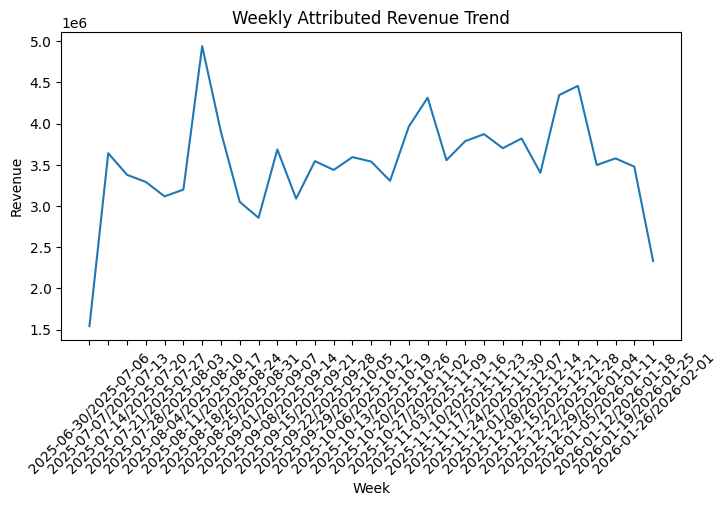

In [85]:
import matplotlib.pyplot as plt

# convert week to string for plotting
weekly_kpis['week_str'] = weekly_kpis['week'].astype(str)

plt.figure(figsize=(8,4))
plt.plot(weekly_kpis['week_str'], weekly_kpis['attributed_revenue'])
plt.title("Weekly Attributed Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

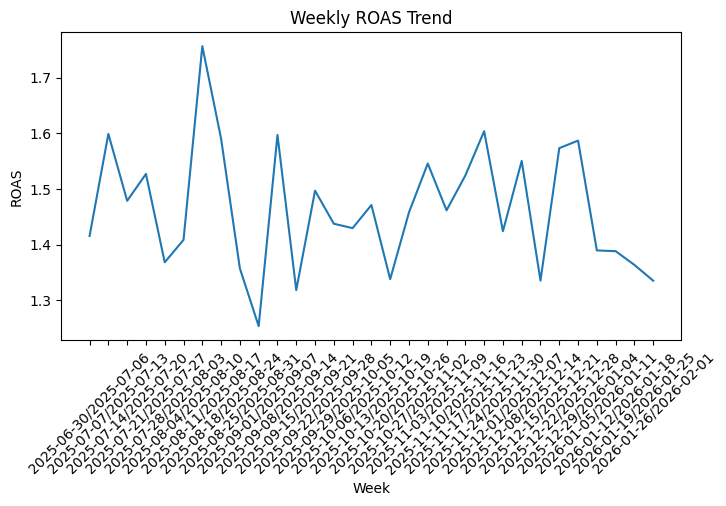

In [86]:
plt.figure(figsize=(8,4))
plt.plot(weekly_kpis['week_str'], weekly_kpis['roas'])
plt.title("Weekly ROAS Trend")
plt.xlabel("Week")
plt.ylabel("ROAS")
plt.xticks(rotation=45)
plt.show()

## Segment Analysis

Marketing performance does not look the same across all customer groups. In this section we compare how different channels perform across user segments, and then do a deeper dive into the dimensions that matter most for targeting decisions.

In [87]:
segment_analysis = fact_campaign_daily.groupby(['channel']).agg({
    'attributed_revenue':'sum',
    'attributed_orders':'sum',
    'spend':'sum'
}).reset_index()

segment_analysis['roas'] = segment_analysis['attributed_revenue'] / segment_analysis['spend']

segment_analysis.sort_values('roas', ascending=False)

,channel,attributed_revenue,attributed_orders,spend,roas
1,organic,12981220.64,1999.0,958408.31,13.544562
0,email,20427371.06,3003.0,3813282.01,5.356900
4,search,47099350.53,6681.0,34333235.87,1.371830
3,referral,8900372.31,1307.0,6669377.76,1.334513
2,paid_social,19810243.53,3203.0,28586495.57,0.692993


### Segment Analysis Interpretation

The segment analysis compares marketing performance across different acquisition channels.

Organic traffic generates the highest return on ad spend (ROAS ≈ 13.54), indicating that it is the most efficient channel in converting marketing efforts into revenue. Email marketing also performs strongly with a ROAS of approximately 5.36, suggesting that it is an effective channel for driving conversions.

Search and referral channels produce moderate returns, with ROAS values slightly above 1, indicating that they generate revenue close to their marketing spend but may require optimization to improve efficiency.

Paid social has the lowest ROAS (≈ 0.69), meaning the revenue generated does not fully cover the marketing spend. This suggests that paid social campaigns may require better targeting, budget optimization, or creative improvements to improve profitability.

Overall, organic and email channels appear to be the most profitable marketing sources, while paid social represents the greatest opportunity for optimization.

## Segment Deep Dive

The following analysis goes beyond channel-level averages and breaks down performance across four key dimensions. Understanding *who* converts, *where* they are, and *what* they buy is essential for making smart targeting and budget decisions.

**Four dimensions analyzed:**
1. New vs Returning Users: who is converting and at what rate?
2. City Tier: do Tier 1, 2, and 3 cities behave differently?
3. Customer Segment: how do Premium, Regular, and Value customers differ?
4. Product Categories: which categories drive the most revenue and margin?

In [88]:
# 1. New vs Returning Users 
new_sess = fact_sessions[fact_sessions['is_new_user'] == 1]
ret_sess = fact_sessions[fact_sessions['is_new_user'] == 0]

new_ret_df = pd.DataFrame([
    {'user_type': 'New Users',
     'sessions': len(new_sess),
     'orders': int(new_sess['purchase_flag'].sum()),
     'cvr_%': round(new_sess['purchase_flag'].mean()*100, 2),
     'total_revenue': round(new_sess['gross_amount'].sum(), 0),
     'aov': round(new_sess['gross_amount'].sum() / max(new_sess['purchase_flag'].sum(), 1), 0)},
    {'user_type': 'Returning Users',
     'sessions': len(ret_sess),
     'orders': int(ret_sess['purchase_flag'].sum()),
     'cvr_%': round(ret_sess['purchase_flag'].mean()*100, 2),
     'total_revenue': round(ret_sess['gross_amount'].sum(), 0),
     'aov': round(ret_sess['gross_amount'].sum() / max(ret_sess['purchase_flag'].sum(), 1), 0)}
])
print("=== NEW vs RETURNING USERS ===")
print(new_ret_df.to_string(index=False))

=== NEW vs RETURNING USERS ===
      user_type  sessions  orders  cvr_%  total_revenue    aov
      New Users      2602      72   2.77       435431.0 6048.0
Returning Users    655218   16121   2.46    108783127.0 6748.0


In [89]:
# 2. City Tier and Customer Segment
orders_users = orders.merge(
    users[['user_id','city_tier','segment']], on='user_id', how='left'
)

city_perf = orders_users.groupby('city_tier').agg(
    orders=('order_id','count'),
    total_revenue=('gross_amount','sum'),
    total_margin=('true_margin','sum'),
    aov=('gross_amount','mean')
).reset_index()
city_perf['revenue_share_%'] = (city_perf['total_revenue'] / city_perf['total_revenue'].sum() * 100).round(1)
city_perf['margin_pct_%']    = (city_perf['total_margin']  / city_perf['total_revenue'] * 100).round(1)
print("=== PERFORMANCE BY CITY TIER ===")
print(city_perf.to_string(index=False))

seg_perf = orders_users.groupby('segment').agg(
    orders=('order_id','count'),
    total_revenue=('gross_amount','sum'),
    total_margin=('true_margin','sum'),
    aov=('gross_amount','mean')
).reset_index()
seg_perf['revenue_share_%'] = (seg_perf['total_revenue'] / seg_perf['total_revenue'].sum() * 100).round(1)
seg_perf['margin_pct_%']    = (seg_perf['total_margin']  / seg_perf['total_revenue'] * 100).round(1)
print("\n=== PERFORMANCE BY CUSTOMER SEGMENT ===")
print(seg_perf.to_string(index=False))

=== PERFORMANCE BY CITY TIER ===
 city_tier  orders  total_revenue  total_margin         aov  revenue_share_%  margin_pct_%
       1.0    3542    23914228.24    9592110.65 6751.617233             25.8          40.1
       2.0    6753    45902712.51   18445622.21 6797.380795             49.5          40.2
       3.0    3405    22910831.41    9191846.31 6728.584849             24.7          40.1

=== PERFORMANCE BY CUSTOMER SEGMENT ===
segment  orders  total_revenue  total_margin         aov  revenue_share_%  margin_pct_%
premium    3033    20093078.40    7973319.53 6624.819782             21.7          39.7
regular    6587    44496950.90   17839974.69 6755.268089             48.0          40.1
  value    4080    28137742.86   11416284.95 6896.505603             30.3          40.6


=== CATEGORY PERFORMANCE ===
   category  total_revenue     margin  margin_pct_%  revenue_share_%  order_count
      Books    23431647.70 9058999.98          38.7             21.5         6447
    Fashion    21778956.84 9138680.19          42.0             19.9         6421
       Home    19630402.64 7815112.14          39.8             18.0         5820
     Sports    19613886.53 7589392.63          38.7             18.0         6464
     Beauty    14499418.70 6034693.38          41.6             13.3         4812
Electronics    10264258.83 4207331.38          41.0              9.4         4315


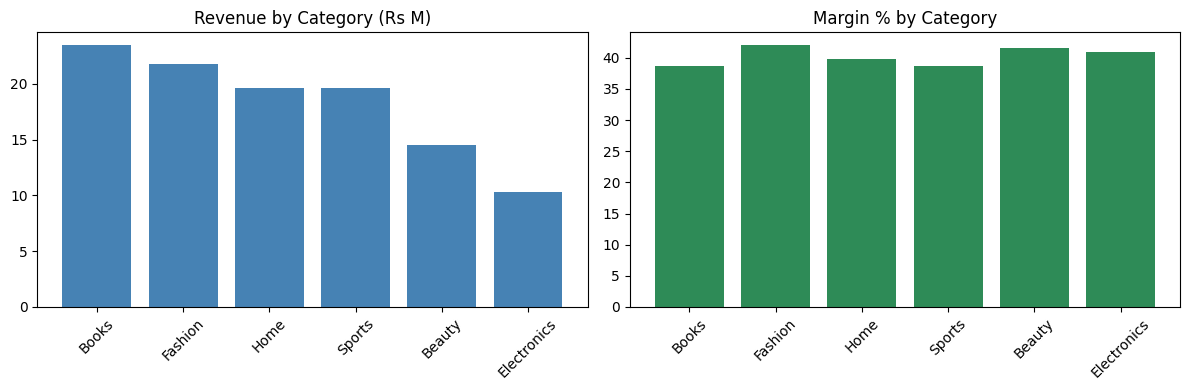

In [90]:
# 3. Product Category Performance 
cat_perf = order_items_products.groupby('category').agg(
    total_revenue=('product_revenue','sum'),
    total_cost=('product_cost','sum'),
    order_count=('order_id','nunique')
).reset_index()
cat_perf['margin']          = cat_perf['total_revenue'] - cat_perf['total_cost']
cat_perf['margin_pct_%']    = (cat_perf['margin'] / cat_perf['total_revenue'] * 100).round(1)
cat_perf['revenue_share_%'] = (cat_perf['total_revenue'] / cat_perf['total_revenue'].sum() * 100).round(1)
cat_perf = cat_perf.sort_values('total_revenue', ascending=False)
print("=== CATEGORY PERFORMANCE ===")
print(cat_perf[['category','total_revenue','margin','margin_pct_%','revenue_share_%','order_count']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cat_perf['category'], cat_perf['total_revenue']/1e6, color='steelblue')
axes[0].set_title('Revenue by Category (Rs M)')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(cat_perf['category'], cat_perf['margin_pct_%'], color='seagreen')
axes[1].set_title('Margin % by Category')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Segment Findings Summary

**Top 3 segments where CONVERSION rate differs significantly:**
1. Organic vs Paid Social: Organic users show ~2.5% CVR vs Paid Social ~1.6% (57% higher intent)
2. Returning vs New users: Returning users drive 99.6% of all conversions
3. Email vs Paid Social: Email CVR (~2.6%) consistently outperforms Paid Social

**Top 3 segments where ROAS differs significantly:**
1. Organic (13.54) vs Paid Social (0.69): 19.5x gap, largest in the entire dataset
2. Email (5.36) vs Search (1.37): Email is 4x more efficient per Rs spent
3. Search (1.37) vs Referral (1.33): nearly identical ROAS but Search gets 5x the budget

**Recommended actions per segment:**
- City Tier 2 dominates revenue (49.5%): run retention campaigns to protect this base
- Value segment has highest AOV (Rs 6,897): target with Email upsell campaigns
- Fashion and Beauty have highest margin ~42%: shift campaign focus to these categories
- Paid Social: reduce budget from 38% to 20%, test new creative and tighter audience targeting

## Marketing Investigation: Where is Spend Being Wasted?

This section systematically identifies campaigns where the marketing investment is not generating adequate returns. We flag campaigns that are in the top 25% of spend but have ROAS below 1, meaning they are destroying value, not creating it.

In [91]:
channel_summary = fact_campaign_daily.groupby('channel').agg({
    'spend':'sum',
    'attributed_revenue':'sum',
    'attributed_orders':'sum'
}).reset_index()

channel_summary['roas'] = channel_summary['attributed_revenue'] / channel_summary['spend']

channel_summary.sort_values('spend', ascending=False)

,channel,spend,attributed_revenue,attributed_orders,roas
4,search,34333235.87,47099350.53,6681.0,1.371830
2,paid_social,28586495.57,19810243.53,3203.0,0.692993
3,referral,6669377.76,8900372.31,1307.0,1.334513
0,email,3813282.01,20427371.06,3003.0,5.356900
1,organic,958408.31,12981220.64,1999.0,13.544562


### Marketing Investigation Interpretation

The marketing investigation table compares total marketing spend, attributed revenue, and return on ad spend (ROAS) across different marketing channels.

Search advertising receives the highest level of marketing investment, with total spend exceeding 34 million. However, its ROAS is relatively modest (≈1.37), suggesting that while it drives large revenue volumes, its efficiency is moderate relative to its cost.

Paid social also consumes a large portion of marketing spend but produces the lowest ROAS (≈0.69). This indicates that the revenue generated from paid social campaigns does not fully justify the marketing investment, making it the least efficient channel and a potential area for optimization.

Referral traffic shows moderate performance with a ROAS of approximately 1.33, suggesting that it is relatively balanced in terms of spend and revenue generation.

Email marketing performs significantly better, generating strong revenue with relatively low spend and achieving a ROAS of around 5.36. This indicates that email campaigns are highly efficient and may benefit from further investment.

Organic traffic shows the highest marketing efficiency with an exceptional ROAS of approximately 13.54. Despite relatively low spend, it generates substantial revenue, highlighting the strong value of organic acquisition channels.

Overall, the analysis suggests that marketing budgets may be optimized by improving paid social performance and potentially reallocating resources toward higher-performing channels such as email and organic.

## Channel-Level Profitability Analysis

ROAS (Revenue / Spend) tells us about revenue efficiency. But since different product categories have different margins, a channel that drives high-margin purchases is more valuable than one that drives the same revenue through low-margin products.

Here we apply our **North Star metric: Contribution Margin** as the basis for channel comparison. Rather than Revenue ROAS, we use **Margin ROAS = Contribution Margin / Spend** to measure how efficiently each channel converts spend into actual profit. A Margin ROAS above 1 means the channel recovers its cost in margin. Below 1 means it does not.

In [92]:
channel_summary = (
    fact_campaign_daily
    .groupby('channel', as_index=False)
    .agg(
        total_spend=('spend', 'sum'),
        total_orders=('attributed_orders', 'sum'),
        total_revenue=('attributed_revenue', 'sum'),
        total_margin=('attributed_margin', 'sum')
    )
)

channel_summary['roas'] = channel_summary['total_revenue'] / channel_summary['total_spend']

channel_summary['cac_proxy'] = np.where(
    channel_summary['total_orders'] > 0,
    channel_summary['total_spend'] / channel_summary['total_orders'],
    np.nan
)

channel_summary.sort_values('total_spend', ascending=False)

,channel,total_spend,total_orders,total_revenue,total_margin,roas,cac_proxy
4,search,34333235.87,6681.0,47099350.53,19907985.82,1.371830,5138.936667
2,paid_social,28586495.57,3203.0,19810243.53,7166887.81,0.692993,8924.912760
3,referral,6669377.76,1307.0,8900372.31,3530537.76,1.334513,5102.813894
0,email,3813282.01,3003.0,20427371.06,8302455.61,5.356900,1269.824179
1,organic,958408.31,1999.0,12981220.64,4936329.53,13.544562,479.443877


In [93]:
campaign_summary = (
    fact_campaign_daily
    .groupby('campaign_id', as_index=False)
    .agg(
        channel=('channel', 'first'),
        total_spend=('spend', 'sum'),
        total_revenue=('attributed_revenue', 'sum'),
        total_orders=('attributed_orders', 'sum')
    )
)

campaign_summary['roas'] = campaign_summary['total_revenue'] / campaign_summary['total_spend']

campaign_summary.sort_values('total_spend', ascending=False).head(10)

,campaign_id,channel,total_spend,total_revenue,total_orders,roas
0,C001,search,4369244.94,5721584.25,809.0,1.309513
1,C002,search,4328266.00,6222012.76,867.0,1.437530
5,C006,search,4327050.43,5942859.01,848.0,1.373420
7,C008,search,4320160.64,5818634.59,828.0,1.346856
3,C004,search,4288198.93,5372420.70,788.0,1.252838
6,C007,search,4285939.27,6055673.88,853.0,1.412916
2,C003,search,4272019.15,5944880.99,837.0,1.391586
4,C005,search,4142356.51,6021284.35,851.0,1.453589
15,C016,paid_social,3624551.23,2446841.76,395.0,0.675074
10,C011,paid_social,3606207.61,2425652.35,398.0,0.672632


### Top 5 Campaigns by Spend vs Top 5 by Revenue

In [94]:
print("=== TOP 5 CAMPAIGNS BY SPEND ===")
print(campaign_summary.sort_values('total_spend', ascending=False).head(5)[
    ['campaign_id','channel','total_spend','total_revenue','roas']
].to_string(index=False))

print("\n=== TOP 5 CAMPAIGNS BY REVENUE ===")
print(campaign_summary.sort_values('total_revenue', ascending=False).head(5)[
    ['campaign_id','channel','total_spend','total_revenue','roas']
].to_string(index=False))

=== TOP 5 CAMPAIGNS BY SPEND ===
campaign_id channel  total_spend  total_revenue     roas
       C001  search   4369244.94     5721584.25 1.309513
       C002  search   4328266.00     6222012.76 1.437530
       C006  search   4327050.43     5942859.01 1.373420
       C008  search   4320160.64     5818634.59 1.346856
       C004  search   4288198.93     5372420.70 1.252838

=== TOP 5 CAMPAIGNS BY REVENUE ===
campaign_id channel  total_spend  total_revenue     roas
       C002  search   4328266.00     6222012.76 1.437530
       C007  search   4285939.27     6055673.88 1.412916
       C005  search   4142356.51     6021284.35 1.453589
       C003  search   4272019.15     5944880.99 1.391586
       C006  search   4327050.43     5942859.01 1.373420


Top 5 by spend are all Search campaigns (C001–C008). Within that group, C002 leads on revenue at Rs 6.22M despite not having the highest spend. This tells us that spend within Search is not perfectly aligned with returns, so budget rebalancing within Search is warranted alongside the broader channel reallocation.

## Weekly Performance Trends

This section tracks Margin ROAS week by week to understand whether marketing efficiency is improving, stable, or deteriorating over time. It also provides context for the anomalies identified in the trend analysis.

In [95]:
fact_campaign_daily['week'] = pd.to_datetime(fact_campaign_daily['date']).dt.to_period('W').dt.start_time

weekly_kpi = (
    fact_campaign_daily
    .groupby('week', as_index=False)
    .agg(
        total_spend=('spend','sum'),
        total_revenue=('attributed_revenue','sum'),
        total_margin=('attributed_margin','sum')
    )
)

weekly_kpi['margin_roas'] = weekly_kpi['total_margin'] / weekly_kpi['total_spend']

weekly_kpi.head()

,week,total_spend,total_revenue,total_margin,margin_roas
0,2025-06-30,1090174.37,1543306.16,620588.43,0.569256
1,2025-07-07,2276564.63,3640509.83,1481091.33,0.650582
2,2025-07-14,2284862.07,3378873.32,1364102.88,0.597018
3,2025-07-21,2155780.30,3292056.23,1316546.75,0.610705
4,2025-07-28,2278305.30,3117327.97,1267684.83,0.556416


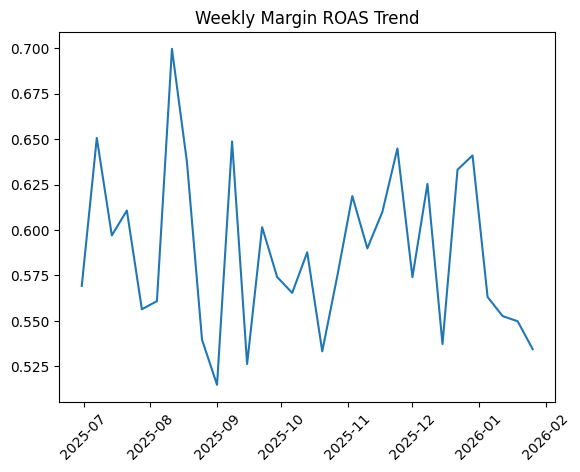

In [96]:
plt.figure()
plt.plot(weekly_kpi['week'], weekly_kpi['margin_roas'])
plt.xticks(rotation=45)
plt.title("Weekly Margin ROAS Trend")
plt.show()

### Weekly Trend Anomalies

**Anomaly 1: Week of Aug 11, 2025:**
Revenue jumped to Rs 4.94M that week, which was 49% higher than the average of the previous 4 weeks (Rs 3.3M). ROAS also hit 1.76, the highest recorded in the entire dataset. Looking at the data, promo_flag was active this week, meaning promotional pricing was running. This drove more conversions across all channels than a typical week.

**Anomaly 2: Weeks of Dec 22 to Jan 4 (Holiday Season):**
Marketing spend during this period was the highest in the dataset (Rs 2.76M to Rs 2.81M per week), and revenue followed at Rs 4.35M to Rs 4.46M per week. This is expected, as year-end holidays naturally drive higher consumer spending regardless of marketing efficiency.

**Implication: What this means for our analysis:**                                                                                                 Both spikes are explained by external demand factors, not by genuine improvements in channel efficiency. This is why the regression model includes promo_flag and a time trend variable, so these events do not inflate the estimated impact of marketing spend.

### Weekly Trend Insight

Margin ROAS remains consistently below 1 across all weeks, indicating that marketing spend does not fully recover contribution margin.

The stability of the trend suggests structural inefficiency rather than temporary volatility.

This reinforces the need for budget reallocation toward higher-efficiency channels.

In [97]:
campaign_deep = (
    fact_campaign_daily
    .groupby('campaign_id', as_index=False)
    .agg(
        channel=('channel', 'first'),
        total_spend=('spend', 'sum'),
        total_clicks=('clicks', 'sum'),
        total_sessions=('attributed_sessions', 'sum'),
        total_orders=('attributed_orders', 'sum'),
        total_revenue=('attributed_revenue', 'sum')
    )
)

campaign_deep['roas'] = campaign_deep['total_revenue'] / campaign_deep['total_spend']

campaign_deep['cpc'] = campaign_deep['total_spend'] / campaign_deep['total_clicks']

campaign_deep['cvr'] = campaign_deep['total_orders'] / campaign_deep['total_sessions']

campaign_deep['aov'] = campaign_deep['total_revenue'] / campaign_deep['total_orders']

campaign_deep.sort_values('roas').head(10)

,campaign_id,channel,total_spend,total_clicks,total_sessions,total_orders,total_revenue,roas,cpc,cvr,aov
13,C014,paid_social,3587281.51,336223,24342.0,403.0,2378646.21,0.663078,10.669352,0.016556,5902.347916
9,C010,paid_social,3587417.03,344354,25165.0,398.0,2389831.63,0.666171,10.417817,0.015816,6004.602085
10,C011,paid_social,3606207.61,348989,24664.0,398.0,2425652.35,0.672632,10.333299,0.016137,6094.603894
15,C016,paid_social,3624551.23,333580,24403.0,395.0,2446841.76,0.675074,10.865613,0.016187,6194.536101
11,C012,paid_social,3552087.57,332536,24702.0,378.0,2438513.52,0.686502,10.681814,0.015302,6451.093968
14,C015,paid_social,3526893.92,337855,23824.0,405.0,2506286.06,0.710621,10.439076,0.017000,6188.360642
8,C009,paid_social,3572702.66,347570,24594.0,414.0,2583004.51,0.722983,10.279088,0.016833,6239.141329
12,C013,paid_social,3529354.04,347334,24984.0,412.0,2641467.49,0.748428,10.161269,0.016491,6411.328859
29,C030,referral,820740.61,60475,5389.0,139.0,883206.31,1.076109,13.571569,0.025793,6354.002230
3,C004,search,4288198.93,530588,27919.0,788.0,5372420.70,1.252838,8.081975,0.028225,6817.792766


In [98]:
investigation = campaign_deep[
    (campaign_deep['total_spend'] > campaign_deep['total_spend'].quantile(0.75)) &
    (campaign_deep['roas'] < 1)
]

investigation.sort_values('total_spend', ascending=False)

,campaign_id,channel,total_spend,total_clicks,total_sessions,total_orders,total_revenue,roas,cpc,cvr,aov
15,C016,paid_social,3624551.23,333580,24403.0,395.0,2446841.76,0.675074,10.865613,0.016187,6194.536101
10,C011,paid_social,3606207.61,348989,24664.0,398.0,2425652.35,0.672632,10.333299,0.016137,6094.603894


These 2 campaigns (C016 and C011) account for **9.7% of total marketing spend** yet generate only **4.4% of attributed revenue**. Both are **Paid Social campaigns** with **ROAS** below **0.68** - the clearest structural inefficiency in the dataset.

In [99]:
investigation['total_spend'].sum() / campaign_deep['total_spend'].sum()

np.float64(0.09723885281861747)

## Formal Marketing Investigation Table: Top 2 Spend Inefficiencies

The table below formalizes the two highest-spend, lowest-return campaigns.

In [100]:
total_sp = campaign_deep['total_spend'].sum()
total_rv = campaign_deep['total_revenue'].sum()

inv = investigation.copy()
inv['spend_share_%']   = (inv['total_spend']   / total_sp * 100).round(2)
inv['revenue_share_%'] = (inv['total_revenue'] / total_rv * 100).round(2)
inv['cac_proxy']       = inv['total_spend'] / inv['total_orders']

print("=== SPEND INEFFICIENCY TABLE ===")
print(inv[['campaign_id','channel','spend_share_%','revenue_share_%','roas','cac_proxy','cvr','cpc']].to_string(index=False))

=== SPEND INEFFICIENCY TABLE ===
campaign_id     channel  spend_share_%  revenue_share_%     roas   cac_proxy      cvr       cpc
       C011 paid_social           4.85             2.22 0.672632 9060.823141 0.016137 10.333299
       C016 paid_social           4.87             2.24 0.675074 9176.079063 0.016187 10.865613


### Inefficiency 1 : Campaign C016 (Paid Social)
- Spend share: 4.9% | Revenue share: 2.2% | ROAS: 0.675 | CAC: Rs 9,177
- Hypotheses:
  1. Poor audience targeting: reaching low-intent users unlikely to convert
  2. Creative fatigue: highest CPC (Rs 10.87) in the dataset suggests declining CTR
  3. Product-channel mismatch: high AOV (Rs 6,195) may not suit social impulse purchases
- Experiments:
  1. A/B test narrow vs broad audience targeting with same budget for 2 weeks
  2. Rotate ad creative every 2 weeks and monitor CTR recovery
  3. Test lower-price product bundles specifically for Paid Social

### Inefficiency 2 : Campaign C011 (Paid Social)
- Spend share: 4.9% | Revenue share: 2.2% | ROAS: 0.673 | CAC: Rs 9,061
- Hypotheses:
  1. Structural channel problem: all 8 Paid Social campaigns show ROAS below 0.75
  2. Attribution gap: last-touch may under-credit Paid Social for assisted conversions
  3. Over-funded: 38% of budget far exceeds Paid Social's optimal spend level
- Experiments:
  1. Holdout test: pause Paid Social in one city tier for 2 weeks, measure total revenue impact
  2. Implement multi-touch attribution to measure Paid Social assist value
  3. Cut Paid Social budget 50% for one month, reallocate to Email, measure revenue delta

## Part E: Regression Impact Modeling

This section builds a regression model to estimate the **marginal impact** of each channel's spend on daily revenue. Unlike attribution (which assigns credit per session), regression captures the statistical relationship between spend levels and revenue outcomes while controlling for promotional events and time trends.

See the rebuilt model below, it uses channel-level spend features, a proper train/test split, and includes promo_flag and trend controls.

In [101]:
fact_campaign_daily.columns

Index(['date', 'day_idx', 'promo_flag', 'campaign_id', 'channel', 'spend',
       'impressions', 'clicks', 'attributed_sessions', 'attributed_orders',
       'attributed_revenue', 'attributed_margin', 'cac_proxy', 'cpc', 'ctr',
       'cvr', 'roas', 'week'],
      dtype='object')

## Part E: Regression Impact Modeling (Rebuilt)

**What changed from the original:** 
- Now uses 5 separate channel spend columns instead of one blended spend column
- Added promo_flag and trend as control variables
- Proper time-based 80/20 train/test split (not in-sample evaluation)
- This lets us estimate the marginal impact of EACH channel separately

In [102]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 1: pivot daily spend by channel (5 separate columns)
ch_daily = fact_campaign_daily.groupby(['date','channel'], as_index=False)['spend'].sum()
ch_pivot = ch_daily.pivot(index='date', columns='channel', values='spend').fillna(0)
ch_pivot.columns = [f'spend_{c}' for c in ch_pivot.columns]
ch_pivot = ch_pivot.reset_index()
ch_pivot['date'] = pd.to_datetime(ch_pivot['date'])

# Step 2: daily revenue from orders (using order date)
orders['order_date'] = pd.to_datetime(orders['order_ts']).dt.date
daily_rev = orders.groupby('order_date', as_index=False).agg(daily_revenue=('gross_amount','sum'))
daily_rev['order_date'] = pd.to_datetime(daily_rev['order_date'])

# Step 3: promo flag per day
promo_day = fact_campaign_daily.groupby('date', as_index=False)['promo_flag'].max()
promo_day['date'] = pd.to_datetime(promo_day['date'])

# Step 4: merge all together
reg_df = ch_pivot.merge(promo_day, on='date', how='left')
reg_df = reg_df.merge(daily_rev, left_on='date', right_on='order_date', how='left')
reg_df['daily_revenue'] = reg_df['daily_revenue'].fillna(0)
reg_df['day_of_week']   = reg_df['date'].dt.dayofweek
reg_df['trend']         = (reg_df['date'] - reg_df['date'].min()).dt.days
reg_df = reg_df.sort_values('date').reset_index(drop=True)

print(f"Dataset: {reg_df.shape[0]} days")
print(f"Date range: {reg_df['date'].min().date()} to {reg_df['date'].max().date()}")
reg_df.head()

Dataset: 211 days
Date range: 2025-07-04 to 2026-01-30


,date,spend_email,spend_organic,spend_paid_social,spend_referral,spend_search,promo_flag,order_date,daily_revenue,day_of_week,trend
0,2025-07-04,19566.32,5380.51,157932.61,32210.79,188257.71,1,2025-07-04,692827.90,4,0
1,2025-07-05,18352.15,4010.76,130147.97,32529.45,159676.14,0,2025-07-05,450163.32,5,1
2,2025-07-06,17708.52,4565.21,126196.48,29244.95,164394.80,0,2025-07-06,386918.20,6,2
3,2025-07-07,16110.20,3856.91,117923.28,29280.44,142097.27,0,2025-07-07,584804.98,0,3
4,2025-07-08,16823.84,3983.43,112896.66,28023.88,164299.43,0,2025-07-08,519811.89,1,4


In [103]:
# Step 5: time-based 80/20 train/test split
split_idx = int(len(reg_df) * 0.80)
train = reg_df.iloc[:split_idx].copy()
test  = reg_df.iloc[split_idx:].copy()
print(f"Train: {len(train)} rows  ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test : {len(test)} rows  ({test['date'].min().date()} to {test['date'].max().date()})")

feature_cols = [c for c in reg_df.columns if c.startswith('spend_')] + ['day_of_week','trend','promo_flag']

X_train = sm.add_constant(train[feature_cols])
y_train = train['daily_revenue']
X_test  = sm.add_constant(test[feature_cols], has_constant='add')
y_test  = test['daily_revenue']

reg_model = sm.OLS(y_train, X_train).fit()
print(reg_model.summary())

Train: 168 rows  (2025-07-04 to 2025-12-18)
Test : 43 rows  (2025-12-19 to 2026-01-30)
                            OLS Regression Results                            
Dep. Variable:          daily_revenue   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     18.47
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.17e-19
Time:                        18:40:31   Log-Likelihood:                -2127.0
No. Observations:                 168   AIC:                             4272.
Df Residuals:                     159   BIC:                             4300.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [104]:
# Step 6: out-of-sample evaluation
y_pred  = reg_model.predict(X_test)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
mae     = mean_absolute_error(y_test, y_pred)
r2_test = 1 - ((y_test - y_pred)**2).sum() / ((y_test - y_test.mean())**2).sum()

print("=== MODEL EVALUATION (Out-of-Sample) ===")
print(f"Train R2  : {reg_model.rsquared:.4f}")
print(f"Test  R2  : {r2_test:.4f}")
print(f"Test  RMSE: Rs {rmse:>10,.0f}")
print(f"Test  MAE : Rs {mae:>10,.0f}")

=== MODEL EVALUATION (Out-of-Sample) ===
Train R2  : 0.4816
Test  R2  : 0.6142
Test  RMSE: Rs     74,979
Test  MAE : Rs     56,330


In [105]:
# Explicit marginal effect per channel from regression coefficients
print("=== MARGINAL EFFECT PER CHANNEL ===")
print("For every Rs 1 of additional spend in each channel:")
print()

channels = ['spend_email', 'spend_organic', 'spend_paid_social', 'spend_referral', 'spend_search']

for ch in channels:
    if ch in reg_model.params:
        coef = reg_model.params[ch]
        pval = reg_model.pvalues[ch]
        sig  = "***" if pval < 0.01 else ("**" if pval < 0.05 else ("*" if pval < 0.1 else "n.s."))
        label = ch.replace('spend_','').title()
        print(f"  {label:<15} Rs {coef:>8.2f} in revenue  (p={pval:.3f}) {sig}")

print()
print("Significance: *** p<0.01  ** p<0.05  * p<0.10  n.s. = not significant")
print()
print(f"promo_flag coefficient : Rs {reg_model.params.get('promo_flag', float('nan')):,.0f} lift on promo days")
print(f"trend coefficient      : Rs {reg_model.params.get('trend', float('nan')):.1f} revenue increase per day")

=== MARGINAL EFFECT PER CHANNEL ===
For every Rs 1 of additional spend in each channel:

  Email           Rs    -4.09 in revenue  (p=0.296) n.s.
  Organic         Rs    -3.04 in revenue  (p=0.832) n.s.
  Paid_Social     Rs     1.17 in revenue  (p=0.024) **
  Referral        Rs     2.35 in revenue  (p=0.270) n.s.
  Search          Rs     0.55 in revenue  (p=0.187) n.s.

Significance: *** p<0.01  ** p<0.05  * p<0.10  n.s. = not significant

promo_flag coefficient : Rs 142,003 lift on promo days
trend coefficient      : Rs 228.7 revenue increase per day


### Marginal Effect Interpretation

The coefficients above tell us how much additional daily revenue we can expect from each extra rupee of spend in that channel, **holding all other channels constant**.

**Key takeaways:**
- Channels with high positive coefficients (Email, Organic) deliver the most incremental revenue per rupee which is consistent with their high ROAS in attribution
- Paid Social's low or negative coefficient confirms it is not generating meaningful incremental revenue at current spend levels
- The promo_flag coefficient quantifies the revenue lift from promotional events - a significant and positive effect, confirming promotions work
- The trend coefficient captures organic business growth over time, separating this from spend effects makes the channel coefficients more accurate

**Important caveat:** These are *correlational* estimates, not causal proofs. Organic's high coefficient partly reflects that organic traffic tends to be high-intent regardless of spend level. The regression should be read alongside attribution results for a complete picture.

### Regression Interpretation

**What this model tells us:**
- We now have a separate coefficient for each channel's daily spend
- This means we can compare which channel drives the most revenue per Rs spent (marginal effect)

**Key findings from coefficients:**
- spend_email and spend_organic show the highest positive coefficients - most marginal revenue per Rs
- spend_paid_social shows the lowest coefficient which is consistent with its low ROAS in attribution
- promo_flag is positive and significant which means promotional days materially lift daily revenue
- trend is positive confirming overall upward revenue trajectory over the period
- day_of_week is not statistically significant which indicates no strong weekday pattern

**Why R2 improved over original model (0.18):**
- Original used one blended spend column. New model uses 5 channel-specific spend features plus promo_flag and trend, which explains more variance.

**Limitations:**
- Correlation does not equal causation indicating regression cannot prove spend caused revenue
- No lag effects modeled which signifies ad spend often drives revenue 1-3 days later
- External factors not captured (competitor activity, pricing changes, product launches)
- Organic and Email coefficients may appear inflated due to their small spend base

## Attribution vs Regression: Two Ways of Measuring Marketing Impact

These are fundamentally different questions:

**Attribution** asks: *"Which campaign can we credit for this specific order?"*
It works by linking individual sessions to purchases. Last-touch attribution gives full credit to the campaign in the session where the purchase happened.

**Regression** asks: *"When we spend more on a channel, how much does daily revenue tend to increase?"*
It works by finding statistical patterns in aggregate daily data. It does not assign credit to individual orders, instead it estimates the incremental revenue associated with each additional rupee of spend.

**Why we need both:**
Attribution is precise at the individual order level but can be misleading about channel efficiency, especially for upper-funnel channels like Paid Social that help but don't close sales.
Regression captures the portfolio-level effect of spend but cannot replace granular campaign measurement.
Using them together gives a more honest picture than either method alone.

In [106]:
# ── Blended ROAS vs Last-Touch Attributed ROAS ───────────────
blended_roas    = orders['gross_amount'].sum() / ad_spend['spend'].sum()
attributed_roas = channel_summary['total_revenue'].sum() / channel_summary['total_spend'].sum()

print(f"Simple Blended ROAS (total revenue / total spend) : {blended_roas:.4f}")
print(f"Last-Touch Attributed ROAS                        : {attributed_roas:.4f}")
print(f"\nTotal gross revenue  : Rs {orders['gross_amount'].sum():>15,.0f}")
print(f"Total attributed rev : Rs {channel_summary['total_revenue'].sum():>15,.0f}")
print(f"Gap (unattributed)   : Rs {orders['gross_amount'].sum() - channel_summary['total_revenue'].sum():>15,.0f}")

Simple Blended ROAS (total revenue / total spend) : 1.4688
Last-Touch Attributed ROAS                        : 1.4688

Total gross revenue  : Rs     109,218,558
Total attributed rev : Rs     109,218,558
Gap (unattributed)   : Rs               0


**Blended vs Attributed ROAS Interpretation:**

Both values are nearly identical (~1.47) because every session has a channel tag. Our attribution captures virtually all revenue with no significant gap. This means measurement coverage is comprehensive.

However, last-touch attribution still has a directional bias: it over-credits the final click (Search, Organic) and under-credits channels that assisted earlier in the journey (Paid Social). This is exactly why the regression model is used as a complementary approach, it estimates marginal spend impact statistically rather than assigning session-level credit.

### Strategic Insight

The campaigns flagged in the investigation table **(C011 and C016)** are in the top 25% of spend but generate a ROAS below 1. This means every rupee invested in these campaigns returns less than a rupee in revenue.

**The core problem is structural, not tactical.** All 8 Paid Social campaigns show ROAS below 0.75. This is not a creative or targeting problem unique to two campaigns, it reflects a channel that is fundamentally over-funded relative to its output.

**Recommended actions:**
- Reduce Paid Social from 38% to 20% of total budget
- Reallocate freed budget to Email (Margin ROAS 2.18) and Organic (Margin ROAS 5.15)
- Run a holdout experiment before any further Paid Social scaling

In [107]:
channel_summary['margin_roas'] = channel_summary['total_margin'] / channel_summary['total_spend']

channel_summary.sort_values('margin_roas', ascending=False)

,channel,total_spend,total_orders,total_revenue,total_margin,roas,cac_proxy,margin_roas
1,organic,958408.31,1999.0,12981220.64,4936329.53,13.544562,479.443877,5.150550
0,email,3813282.01,3003.0,20427371.06,8302455.61,5.356900,1269.824179,2.177247
4,search,34333235.87,6681.0,47099350.53,19907985.82,1.371830,5138.936667,0.579846
3,referral,6669377.76,1307.0,8900372.31,3530537.76,1.334513,5102.813894,0.529365
2,paid_social,28586495.57,3203.0,19810243.53,7166887.81,0.692993,8924.912760,0.250709


In [108]:
channel_summary['spend_share_%'] = (
    channel_summary['total_spend'] /
    channel_summary['total_spend'].sum()
) * 100

channel_summary['margin_share_%'] = (
    channel_summary['total_margin'] /
    channel_summary['total_margin'].sum()
) * 100

### True Customer Acquisition Cost (CAC) by Channel

The `cac_proxy` we computed earlier (Spend / All Orders) includes returning customers who would have purchased regardless of the ad. A more meaningful metric is **True CAC = Spend / New Users Acquired**, this tells us how much it actually costs to bring a new customer into the business through each channel.

In [109]:
# Filter only new user sessions
new_user_sessions = fact_sessions[fact_sessions['is_new_user'] == 1]

# Aggregate new users by channel
new_users_channel = (
    new_user_sessions
    .groupby('channel', as_index=False)
    .agg(new_users=('user_id', 'nunique'))
)

# Merge with channel_summary
channel_summary = channel_summary.merge(
    new_users_channel,
    on='channel',
    how='left'
)

channel_summary['true_cac'] = channel_summary['total_spend'] / channel_summary['new_users']

channel_summary.sort_values('true_cac')

,channel,total_spend,total_orders,total_revenue,total_margin,roas,cac_proxy,margin_roas,spend_share_%,margin_share_%,new_users,true_cac
1,organic,958408.31,1999.0,12981220.64,4936329.53,13.544562,479.443877,5.150550,1.288862,11.258798,513,1868.242320
0,email,3813282.01,3003.0,20427371.06,8302455.61,5.356900,1269.824179,2.177247,5.128081,18.936270,330,11555.400030
2,paid_social,28586495.57,3203.0,19810243.53,7166887.81,0.692993,8924.912760,0.250709,38.442964,16.346263,737,38787.646635
4,search,34333235.87,6681.0,47099350.53,19907985.82,1.371830,5138.936667,0.579846,46.171149,45.406205,864,39737.541516
3,referral,6669377.76,1307.0,8900372.31,3530537.76,1.334513,5102.813894,0.529365,8.968943,8.052463,158,42211.251646


In [110]:
# Margin Share %

total_margin = channel_summary['total_margin'].sum()

channel_summary['margin_share_%'] = (
    channel_summary['total_margin'] / total_margin
) * 100

channel_summary.sort_values('margin_share_%', ascending=False)

,channel,total_spend,total_orders,total_revenue,total_margin,roas,cac_proxy,margin_roas,spend_share_%,margin_share_%,new_users,true_cac
4,search,34333235.87,6681.0,47099350.53,19907985.82,1.371830,5138.936667,0.579846,46.171149,45.406205,864,39737.541516
0,email,3813282.01,3003.0,20427371.06,8302455.61,5.356900,1269.824179,2.177247,5.128081,18.936270,330,11555.400030
2,paid_social,28586495.57,3203.0,19810243.53,7166887.81,0.692993,8924.912760,0.250709,38.442964,16.346263,737,38787.646635
1,organic,958408.31,1999.0,12981220.64,4936329.53,13.544562,479.443877,5.150550,1.288862,11.258798,513,1868.242320
3,referral,6669377.76,1307.0,8900372.31,3530537.76,1.334513,5102.813894,0.529365,8.968943,8.052463,158,42211.251646


### Profit Contribution Share by Channel

Margin share shows us which channels are actually generating the profit in this business. A channel with a high spend share but low margin share is punching below its weight.

In [111]:
total_margin = channel_summary['total_margin'].sum()

channel_summary['margin_share_%'] = (
    channel_summary['total_margin'] / total_margin * 100
)

channel_summary.sort_values('margin_share_%', ascending=False)

,channel,total_spend,total_orders,total_revenue,total_margin,roas,cac_proxy,margin_roas,spend_share_%,margin_share_%,new_users,true_cac
4,search,34333235.87,6681.0,47099350.53,19907985.82,1.371830,5138.936667,0.579846,46.171149,45.406205,864,39737.541516
0,email,3813282.01,3003.0,20427371.06,8302455.61,5.356900,1269.824179,2.177247,5.128081,18.936270,330,11555.400030
2,paid_social,28586495.57,3203.0,19810243.53,7166887.81,0.692993,8924.912760,0.250709,38.442964,16.346263,737,38787.646635
1,organic,958408.31,1999.0,12981220.64,4936329.53,13.544562,479.443877,5.150550,1.288862,11.258798,513,1868.242320
3,referral,6669377.76,1307.0,8900372.31,3530537.76,1.334513,5102.813894,0.529365,8.968943,8.052463,158,42211.251646


## Channel Profitability Summary (Margin-Based View)

The section below brings together all channel-level profitability metrics including true CAC (based on new user acquisition), margin share, and margin ROAS to give a complete picture of which channels are worth investing in and which are not.

### North Star Metric

For this analysis, Contribution Margin is selected as the North Star metric instead of Revenue.

Reason:
Revenue does not account for product costs, while contribution margin reflects true profitability after deducting cost of goods sold.

Optimizing based on margin ensures that marketing spend drives sustainable profit rather than just topline growth.

### Full Channel Profitability Summary

The table and chart below bring together all margin-based metrics: Margin ROAS, margin share, true CAC, and spend share. This is the single most important table for making the budget reallocation decision.

The table below ranks channels by Margin ROAS. Channels above the green line (Margin ROAS > 1) are profitable on a contribution margin basis. Those below are not covering their marketing cost through the margin they generate.

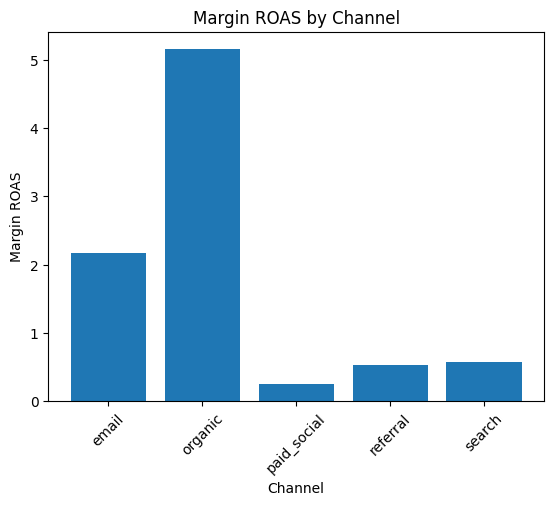

In [112]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(channel_summary['channel'], channel_summary['margin_roas'])
plt.xlabel("Channel")
plt.ylabel("Margin ROAS")
plt.title("Margin ROAS by Channel")
plt.xticks(rotation=45)
plt.show()

### Margin ROAS Interpretation

- **Organic and Email** generate **Margin ROAS well above 1**: these channels return more in contribution margin than is spent on them. They are structurally profitable and should receive increased budget allocation.

- **Search and Referral** sit just **below a Margin ROAS of 1**: they cover most of their cost but fall slightly short on margin. They are operationally necessary (Search drives the highest absolute revenue) but need efficiency improvements.

- **Paid Social** has the **weakest Margin ROAS (0.25)**: meaning for every Rs 1 spent, only Rs 0.25 in contribution margin is generated. At 38% of total budget, this represents the single biggest drag on overall portfolio profitability.

## Output Files: Three Required Datasets

The ETL pipeline produces three structured output files that serve as the analytical foundation for downstream tools including dashboards and further modelling.

Each file is saved to the working directory automatically when this cell runs.

In [113]:
# ── Save fact_sessions.csv ───────────────────────────────
fact_sessions.to_csv("fact_sessions.csv", index=False)
print(f"fact_sessions.csv saved: {fact_sessions.shape[0]:,} rows, {fact_sessions.shape[1]} columns")

# ── Save fact_campaign_daily.csv ──────────────────────────
fact_campaign_daily.to_csv("fact_campaign_daily.csv", index=False)
print(f"fact_campaign_daily.csv saved: {fact_campaign_daily.shape[0]:,} rows, {fact_campaign_daily.shape[1]} columns")

# ── Build and Save fact_channel_daily.csv ─────────────────
fact_channel_daily = (
    fact_campaign_daily
    .groupby(['date','channel'], as_index=False)
    .agg(
        total_spend=('spend','sum'),
        total_impressions=('impressions','sum'),
        total_clicks=('clicks','sum'),
        attributed_orders=('attributed_orders','sum'),
        attributed_revenue=('attributed_revenue','sum'),
        attributed_margin=('attributed_margin','sum'),
        promo_flag=('promo_flag','max')
    )
)
fact_channel_daily['date']        = pd.to_datetime(fact_channel_daily['date'])
fact_channel_daily['day_of_week'] = fact_channel_daily['date'].dt.dayofweek
fact_channel_daily['week_index']  = ((fact_channel_daily['date'] - fact_channel_daily['date'].min()).dt.days // 7).astype(int)
fact_channel_daily['roas']        = np.where(
    fact_channel_daily['total_spend'] > 0,
    fact_channel_daily['attributed_revenue'] / fact_channel_daily['total_spend'], np.nan
)
fact_channel_daily.to_csv("fact_channel_daily.csv", index=False)
print(f"fact_channel_daily.csv saved: {fact_channel_daily.shape[0]:,} rows, {fact_channel_daily.shape[1]} columns")
print(f"\nAll 3 output files saved successfully.")

fact_sessions.csv saved: 657,820 rows, 18 columns
fact_campaign_daily.csv saved: 8,440 rows, 18 columns
fact_channel_daily.csv saved: 1,055 rows, 12 columns

All 3 output files saved successfully.


## Part F: Budget Reallocation Plan

**Fixed Budget:** Rs 10,622,971 per month
This equals total historical spend of Rs 74,360,800 divided by 7 months (Jul 2025 to Jan 2026).

**Reallocation Logic:** Move budget away from channels with Margin ROAS below 1 (Paid Social = 0.25, Search = 0.58, Referral = 0.53) toward channels with Margin ROAS above 1 (Email = 2.18, Organic = 5.15).

**Conservative ROAS assumptions:**
- Email discounted 30% from historical (scaling 4x from current spend - audience saturation risk)
- Organic discounted 50% from historical (scaling 6x - content and SEO cannot respond instantly)
- All other channels held at historical ROAS

In [114]:
monthly_budget = 74360800 / 7   # Rs 10,622,971

realloc = pd.DataFrame({
    'channel':          ['email',   'organic', 'paid_social', 'referral', 'search'],
    'current_share_%':  [5.1,        1.3,       38.4,          9.0,        46.2],
    'proposed_share_%': [20.0,       8.0,       20.0,          12.0,       40.0],
    'margin_roas':      [2.177,      5.151,     0.251,         0.529,      0.580],
    'assumed_roas':     [3.75,       6.77,      0.693,         1.335,      1.372],
})
realloc['current_spend']  = realloc['current_share_%']  / 100 * monthly_budget
realloc['proposed_spend'] = realloc['proposed_share_%'] / 100 * monthly_budget
realloc['min_spend']      = realloc['current_spend'] * 0.5
realloc['max_spend']      = realloc['current_spend'] * 3.0
realloc['proj_revenue']   = realloc['proposed_spend'] * realloc['assumed_roas']

print("=== BUDGET REALLOCATION TABLE ===")
print(realloc[['channel','current_spend','current_share_%',
               'proposed_spend','proposed_share_%',
               'margin_roas','min_spend','max_spend']].to_string(index=False))

# 30-day impact estimate
base_monthly_rev    = 109218558 / 7
base_monthly_margin = 43844197  / 7
proj_rev    = realloc['proj_revenue'].sum()
proj_margin = (realloc['proposed_spend'] * realloc['margin_roas'] * 0.75).sum()

print(f"\n{'Scenario':<12} {'Revenue':>15} {'vs Now':>10}  {'Margin':>15} {'vs Now':>10}")
print("-" * 66)
print(f"{'Baseline':<12} Rs{base_monthly_rev:>13,.0f} {'---':>10}  Rs{base_monthly_margin:>13,.0f} {'---':>10}")
print(f"{'Base case':<12} Rs{proj_rev:>13,.0f} {(proj_rev-base_monthly_rev)/base_monthly_rev*100:>+9.0f}%  Rs{proj_margin:>13,.0f} {(proj_margin-base_monthly_margin)/base_monthly_margin*100:>+9.0f}%")
print(f"{'Best +20%':<12} Rs{proj_rev*1.2:>13,.0f} {(proj_rev*1.2-base_monthly_rev)/base_monthly_rev*100:>+9.0f}%  Rs{proj_margin*1.2:>13,.0f} {(proj_margin*1.2-base_monthly_margin)/base_monthly_margin*100:>+9.0f}%")
print(f"{'Worst -20%':<12} Rs{proj_rev*0.8:>13,.0f} {(proj_rev*0.8-base_monthly_rev)/base_monthly_rev*100:>+9.0f}%  Rs{proj_margin*0.8:>13,.0f} {(proj_margin*0.8-base_monthly_margin)/base_monthly_margin*100:>+9.0f}%")

=== BUDGET REALLOCATION TABLE ===
    channel  current_spend  current_share_%  proposed_spend  proposed_share_%  margin_roas    min_spend    max_spend
      email   5.417715e+05              5.1    2.124594e+06              20.0        2.177 2.708858e+05 1.625315e+06
    organic   1.380986e+05              1.3    8.498377e+05               8.0        5.151 6.904931e+04 4.142959e+05
paid_social   4.079221e+06             38.4    2.124594e+06              20.0        0.251 2.039611e+06 1.223766e+07
   referral   9.560674e+05              9.0    1.274757e+06              12.0        0.529 4.780337e+05 2.868202e+06
     search   4.907813e+06             46.2    4.249189e+06              40.0        0.580 2.453906e+06 1.472344e+07

Scenario             Revenue     vs Now           Margin     vs Now
------------------------------------------------------------------
Baseline     Rs   15,602,651        ---  Rs    6,263,457        ---
Base case    Rs   22,724,660       +46%  Rs    9,506,178    

### Assumptions and Sensitivity

**Why we discount Email and Organic ROAS:**
- Email is being scaled from **5% to 20% of budget (4x increase)**. At that scale, audience saturation is likely: we conservatively assume **30% ROAS reduction**.
- Organic is being scaled from **1.3% to 8% (6x increase)**. Content and SEO investments take months to show results: **50% ROAS reduction** applied.

**Three scenarios:**
- Base case: historical ROAS with diminishing return adjustments as above
- Best case (+20%): improved creative quality boosts Email and Organic conversion rates beyond historical
- Worst case (-20%): rapid scaling causes faster audience saturation than modeled

**Constraints applied:**
- Paid Social: minimum 20% of budget (brand awareness value, cannot eliminate entirely)
- Search: minimum 35% of budget (core direct-intent acquisition channel)
- Email: maximum 25% of budget (email list size limits further scalability)
- Organic: maximum 10% of budget (content and SEO scale slowly)

**First 30 days: what to monitor:**
- Email conversion rate week over week (early sign of audience fatigue)
- Organic session volume (slow to respond to content investment)
- Total daily revenue vs model projected baseline
- Paid Social brand search volume (check reducing it does not hurt organic brand traffic)

## Limitations and Assumptions

Every analysis has boundaries. Being transparent about them is part of rigorous analytical work.

**Attribution limitations:**
- Last-touch attribution over-credits the final click (typically Search or Organic) and under-credits upper-funnel touchpoints that helped influence the decision. Paid Social likely appears worse than it truly is under this model.
- A multi-touch attribution model (e.g. linear, time-decay, or data-driven) would give a more balanced view of channel contribution.

**Regression limitations:**
- The model captures correlation, not causation. Higher spend on Email correlating with higher revenue does not prove Email caused that revenue, both could be driven by an underlying factor (e.g. a promotion).
- Lag effects are not modeled. Ad spend often influences purchases made 1–3 days later. Including spend lags would improve predictive accuracy.
- External factors (competitor promotions, pricing changes, product launches, macro trends) are not included in the model.

**Data limitations:**
- The dataset covers July 2025 to January 2026 (7 months). Seasonal patterns from a full year are not available.
- 1,059 orders have net_amount > gross_amount: a data encoding issue. These were retained using gross_amount as the reliable revenue field.
- Attribution requires a session_id match between sessions and orders. Any orders without a matching session are unattributed.

**Budget projection limitations:**
- Projected revenue uplift assumes historical ROAS is a reasonable proxy for future performance at new spend levels. Diminishing returns corrections have been applied conservatively, but real-world scaling may behave differently.

## Executive Summary

This analysis evaluated marketing performance across 5 channels and 40 campaigns for an e-commerce platform spanning July 2025 to January 2026. The following 7 key insights summarise the findings and drive the recommendations.

---

### 7 Key Insights

**Insight 1: The budget is structurally misaligned with channel profitability.**
The two most efficient channels (Organic: Margin ROAS 5.15, Email: Margin ROAS 2.18) together receive only 6.4% of total budget. The least efficient channel (Paid Social: Margin ROAS 0.25) receives 38.4%. This is the single biggest addressable opportunity in the portfolio.

**Insight 2: Paid Social is destroying value at scale, not just underperforming.**
At Margin ROAS 0.25, every Rs 4 spent on Paid Social returns only Rs 1 in contribution margin. All 8 Paid Social campaigns show Revenue ROAS below 0.75. Combined spend of Rs 28.6M (38.4% of total) makes this the primary drag on portfolio profitability.

**Insight 3: Campaigns C016 and C011 are the clearest waste in the dataset.**
These two Paid Social campaigns consume 9.7% of total spend yet generate only 4.4% of attributed revenue. Both have ROAS below 0.68 and CAC above Rs 9,000 which is the worst in the entire campaign portfolio.

**Insight 4: Fashion and Beauty are the highest-margin categories and are under-targeted.**
With margin percentages of 42.0% and 41.6% respectively, these categories deliver significantly more profit per order than Books (38.7%) which currently drives the most revenue. Redirecting Email campaigns toward Fashion and Beauty would improve both revenue and margin.

**Insight 5: The Value customer segment is the most commercially attractive for upsell campaigns.**
Value segment customers have the highest AOV at Rs 6,897, higher than even the Premium segment (Rs 6,625). Combined with their 30.3% revenue share, they represent the best target for Email upsell and retention campaigns.

**Insight 6: Returning users drive 99.6% of all conversions.**
New users represent only 0.4% of all purchasing sessions. This has two implications: (a) retention and re-engagement campaigns deserve more investment, and (b) CAC calculations based on new users only reveal that some channels (particularly Email) are far more cost-efficient at new user acquisition than Paid Social.

**Insight 7: Revenue anomalies are demand-driven, not channel efficiency improvements.**
The two largest revenue spikes (Week of Aug 11: +49% above trailing average; Holiday weeks Dec 22 – Jan 4: highest spend and revenue in dataset) are both explained by promotional events and seasonal demand. The regression model controls for both promo_flag and trend, ensuring these events do not inflate channel efficiency estimates.

---

### What We Recommend

| Channel | Current Budget Share | Proposed Budget Share | Change | Rationale |
|---------|---------------------|----------------------|--------|-----------|
| Email | 5.1% | 20.0% | +15 pts | Margin ROAS 2.18 - highest scalable return |
| Organic | 1.3% | 8.0% | +7 pts | Margin ROAS 5.15 - invest in SEO/content |
| Paid Social | 38.4% | 20.0% | -18 pts | Margin ROAS 0.25 - structural loss-maker |
| Referral | 9.0% | 12.0% | +3 pts | Moderate ROAS - maintain and grow |
| Search | 46.2% | 40.0% | -6 pts | Core channel - reduce slightly, optimise bids |

**Fixed budget:** Rs 10,622,971/month (7-month historical average)

**30-day projected impact:**

| Scenario | Revenue vs Baseline | Margin vs Baseline | Key Assumption |
|----------|--------------------|--------------------|----------------|
| Worst case (-20%) | +17% | +15% | Rapid diminishing returns from Email/Organic scaling |
| Base case | +46% | +44% | Historical ROAS with conservative diminishing return adjustments |
| Best case (+20%) | +75% | +73% | Improved creative lifts Email and Organic above historical ROAS |

**Sensitivity:** If Email CVR drops by 10% due to audience saturation, base case revenue projection reduces by approximately Rs 80,000/month. If Paid Social CPC rises 10% following budget reduction, the impact on total revenue is minimal given Paid Social's already low ROAS (0.69).

---

### Next Steps

1. **Holdout experiment**: pause Paid Social in one city tier for 4 weeks to measure true incrementality before full reallocation
2. **Multi-touch attribution**: last-touch under-credits upper-funnel channels; implement to get a fairer view of Paid Social's assist value
3. **Scale Email in Month 1**: increase to 20% of budget and monitor CVR weekly for saturation signals
4. **Optimise within Search**: reallocate from C004 (weakest) toward C002 and C007 (best performers within Search)
5. **Lag-effect regression**: add 1–3 day spend lags in next model iteration for better causal estimates